# Proyecto Integrador de PLN — Primer corte
## Detección de tema en chats de Atención Ciudadana del RUTS (Hidalgo)

**Alumno:** Víctor Manuel Santos Martínez · Jessica Melani Romero Lora **Matrícula:** 253220020 · 253220116 **Grupo:** 3°A  
**Materia:** Procesamiento de Lenguaje Natural · **Docente:** M.C. Pablo Ricardo Sánchez Gómez  
**Fecha:** 29 de mayo de 2026

---

### 1. Definición del problema

La Subdirección de Atención Ciudadana del **RUTS** (Registro Único de Trámites y Servicios del Estado de Hidalgo) recibe a diario consultas por chat sobre trámites muy diversos: actas del registro civil, placas vehiculares, predial e impuestos, becas, avisos sanitarios, etc. Hoy esas conversaciones se atienden y archivan sin una clasificación temática sistemática.

**Tarea de PLN (detección de tema):** dado el texto de una conversación ciudadana, asignarle la **categoría de trámite** a la que corresponde. Es un problema de *clasificación de texto en español* sobre lenguaje real, informal y abreviado.

**Por qué es adecuado para PLN:** los chats son texto libre en español, con ruido (faltas de ortografía, mayúsculas, datos personales) y una intención implícita que debe inferirse del contenido — exactamente el tipo de problema que la representación y clasificación de texto resuelve.

> **Alcance de este corte:** definición del problema, construcción del corpus inicial, limpieza/normalización, tokenización y **exploración**. La vectorización y el modelado corresponden al 2.º corte.

**Fuente de datos:** export de 2,014 conversaciones (≈31,600 mensajes) del chat del RUTS, obtenido vía COEMERE. Los datos crudos contienen información personal y **se procesan fuera del repositorio**; al corpus solo se integra texto anonimizado (cumplimiento LGPDPSO).

In [3]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importamos el pipeline del proyecto (lógica reproducible en src/pipeline.py)
PROJ = Path.cwd().parent
sys.path.append(str(PROJ / "src"))
import pipeline as pl

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
FIG = PROJ / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("Pipeline cargado. Fuente cruda:", pl.RAW_MENSAJES.name)

ModuleNotFoundError: No module named 'pandas'

### 2. Construcción del corpus y anonimización

Cada conversación se convierte en **un documento** concatenando únicamente los mensajes del *visitante* (las palabras del ciudadano). Antes de integrarlo al corpus se aplica anonimización (LGPDPSO):

| Marcador | Qué reemplaza |
|----------|----------------|
| `[NOMBRE]` | nombre del visitante y nombres de pila en texto libre |
| `[EMAIL]` | correos electrónicos |
| `[CURP]` / `[RFC]` | claves CURP y RFC |
| `[TEL]` / `[NUM]` | teléfonos y folios/números largos |

Se descartan los chats sin pregunta real (saludos/agradecimientos sueltos): se exige un mínimo de **3 tokens con contenido**.

In [ ]:
corpus = pl.construir_corpus()
print(f"Documentos en el corpus: {len(corpus)}")
corpus.head(5)[["id", "texto", "etiqueta", "n_tokens"]]

: 

In [ ]:
mask = corpus["texto"].str.contains(r"\[NOMBRE\]|\[EMAIL\]|\[RFC\]|\[TEL\]", regex=True)
for t in corpus.loc[mask, "texto"].head(4):
    print("•", t[:160])

fuga = corpus["texto"].str.contains(r"@\w|https?://|\b\d{7,}\b", regex=True).sum()
print(f"\nFilas con PII estructurada residual: {fuga}")

### 3. Descripción de las etiquetas (categorías tentativas)

El etiquetado de este corte es **tentativo y por supervisión débil**: se asigna la categoría a partir de dos señales, en orden de prioridad:

1. **Señal fuerte —** el término de búsqueda con el que el ciudadano llegó al chat (parámetro `text=` del *referer*).
2. **Señal débil —** coincidencia de palabras clave de la taxonomía dentro del texto de la conversación.

Si ninguna señal aplica, el documento queda como `sin_clasificar` (pendiente de revisión manual en el 2.º corte).

| Etiqueta | Trámites representativos |
|----------|--------------------------|
| `registro_civil` | actas de nacimiento, matrimonio, defunción, divorcio; CURP |
| `vehicular` | placas, verificación, infracciones, tenencia, cambio de propietario |
| `impuestos_predial` | predial, ISN/nómina, opinión de cumplimiento, no deudor moroso |
| `educacion` | becas, vales de útiles/uniformes, certificados escolares |
| `salud_sanitario` | aviso de funcionamiento, constancia sanitaria, residuos, agua |
| `empleo` | bolsa de trabajo, vacantes |
| `seguridad_juridica` | antecedentes no penales, denuncias, constancias |
| `sin_clasificar` | sin señal suficiente (a etiquetar manualmente) |

### 4. Limpieza, normalización y tokenización

El pipeline aplica, sobre el texto ya anonimizado:

1. **Normalización:** minúsculas, eliminación de acentos (Unicode NFKD) y de todo lo que no sea letra.
2. **Tokenización:** separación por espacios, descarte de tokens de 1 carácter.
3. **Stopwords:** remoción de conectores y cortesías frecuentes en chat (`hola`, `gracias`, `por favor`, …) que no aportan tema.

Ejemplo paso a paso sobre un documento real:

In [ ]:
ejemplo = corpus.iloc[2]["texto"]
print("1. Original anonimizado:\n  ", ejemplo[:160], "\n")

norm = pl.normalizar(ejemplo)
print("2. Normalizado:\n  ", norm[:160], "\n")

print("3. Tokens (con stopwords):\n  ", pl.tokenizar(norm, quitar_stop=False)[:20], "\n")
print("4. Tokens (sin stopwords):\n  ", pl.tokenizar(norm, quitar_stop=True)[:20])

1. Original anonimizado:
   Hola, buenas tardes. donde puedo tramitar las placas para carro clasico y cuales son los requisitos [NOMBRE] y el proceso solo se realiza en Pachuca? OK GRACIAS 

2. Normalizado:
   hola buenas tardes donde puedo tramitar las placas para carro clasico y cuales son los requisitos nombre y el proceso solo se realiza en pachuca ok gracias no g 

3. Tokens (con stopwords):
   ['hola', 'buenas', 'tardes', 'donde', 'puedo', 'tramitar', 'las', 'placas', 'para', 'carro', 'clasico', 'cuales', 'son', 'los', 'requisitos', 'nombre', 'el', 'proceso', 'solo', 'se'] 

4. Tokens (sin stopwords):
   ['tramitar', 'placas', 'carro', 'clasico', 'cuales', 'son', 'requisitos', 'proceso', 'realiza', 'pachuca']


### 5. Exploración del corpus

#### 5.1 Estadísticas generales

In [ ]:
r = pl.resumen(corpus)
print(f"Documentos ............ {r['documentos']:>6}")
print(f"Vocabulario (únicos) .. {r['vocabulario']:>6}")
print(f"Tokens totales ........ {r['tokens_totales']:>6}")
print(f"Long. media (tokens) .. {r['long_media_tokens']:>6}")
print(f"Long. mediana ......... {r['long_mediana_tokens']:>6}")

Documentos ............   1789
Vocabulario (únicos) ..   6356
Tokens totales ........  31469
Long. media (tokens) ..  17.59
Long. mediana .........     14


#### 5.2 Distribución de etiquetas

etiqueta
sin_clasificar        616
vehicular             303
registro_civil        259
impuestos_predial     239
educacion             155
seguridad_juridica     92
salud_sanitario        83
empleo                 42
Name: count, dtype: int64 

Documentos con etiqueta de tema: 1173  (mínimo del corte: 300)


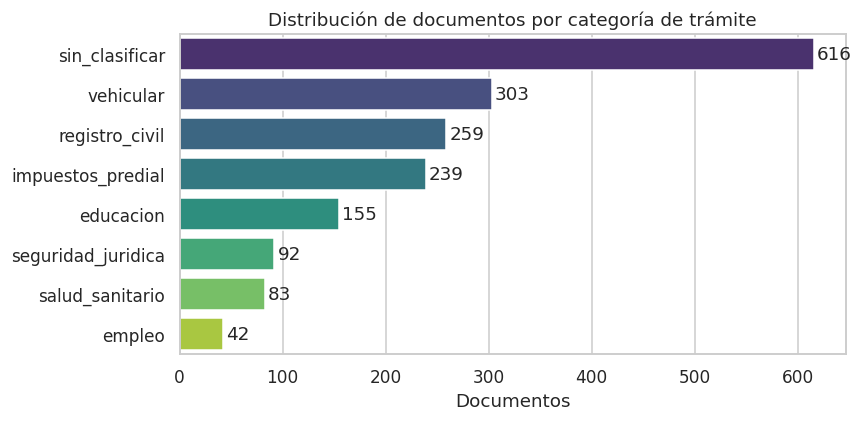

In [ ]:
dist = corpus["etiqueta"].value_counts()
print(dist, "\n")
labeled = int(dist.drop("sin_clasificar", errors="ignore").sum())
print(f"Documentos con etiqueta de tema: {labeled}  (mínimo del corte: 300)")

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=dist.values, y=dist.index, hue=dist.index, palette="viridis", legend=False, ax=ax)
for i, v in enumerate(dist.values):
    ax.text(v + 3, i, str(v), va="center")
ax.set_title("Distribución de documentos por categoría de trámite")
ax.set_xlabel("Documentos"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG / "01_distribucion_etiquetas.png", bbox_inches="tight")
plt.show()

#### 5.3 Longitud de los documentos (en tokens)

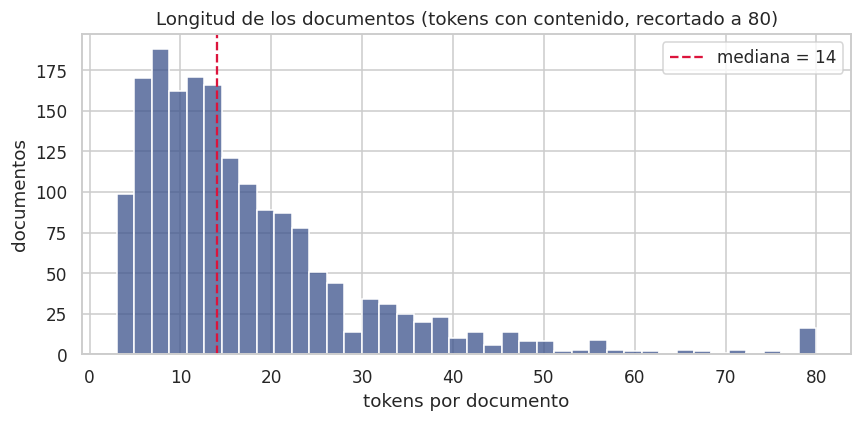

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(corpus["n_tokens"].clip(upper=80), bins=40, color="#3b528b", ax=ax)
ax.axvline(corpus["n_tokens"].median(), color="crimson", ls="--", label=f"mediana = {int(corpus['n_tokens'].median())}")
ax.set_title("Longitud de los documentos (tokens con contenido, recortado a 80)")
ax.set_xlabel("tokens por documento"); ax.set_ylabel("documentos")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "02_longitud_documentos.png", bbox_inches="tight")
plt.show()

#### 5.4 Términos más frecuentes del corpus

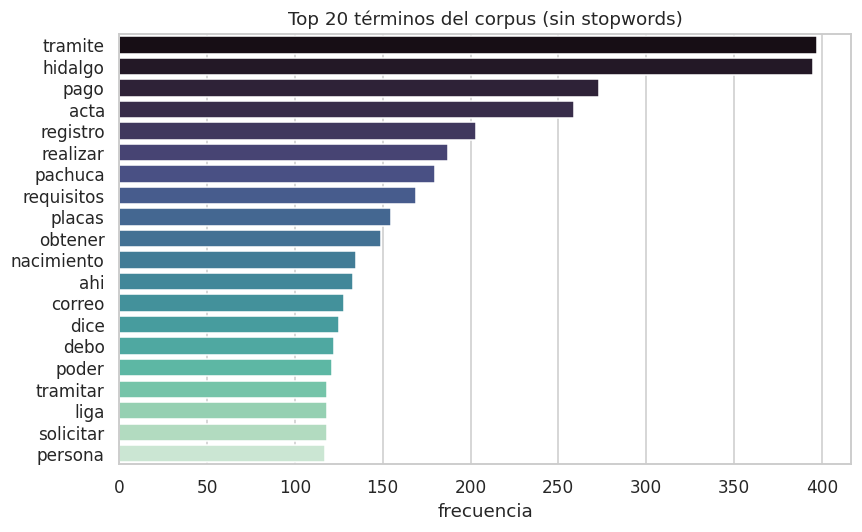

In [ ]:
vocab = pl.construir_vocabulario(corpus)
top = pd.DataFrame(vocab.most_common(20), columns=["termino", "frecuencia"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top, x="frecuencia", y="termino", hue="termino", palette="mako", legend=False, ax=ax)
ax.set_title("Top 20 términos del corpus (sin stopwords)")
ax.set_xlabel("frecuencia"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG / "03_top_terminos.png", bbox_inches="tight")
plt.show()

In [ ]:
# Términos más frecuentes por categoría (exploración cualitativa de las etiquetas)
from collections import Counter
for cat in ["registro_civil", "vehicular", "impuestos_predial", "educacion"]:
    c = Counter()
    for t in corpus.loc[corpus["etiqueta"] == cat, "texto_norm"]:
        c.update(pl.tokenizar(t))
    top_cat = ", ".join(w for w, _ in c.most_common(8))
    print(f"{cat:18s}: {top_cat}")

registro_civil    : acta, nacimiento, tramite, curp, hidalgo, registro, matrimonio, defuncion
vehicular         : placas, pago, verificacion, tramite, vehiculo, hidalgo, vehicular, realizar
impuestos_predial : pago, tramite, pagar, nomina, impuesto, hidalgo, constancia, predial
educacion         : utiles, descargar, secundaria, certificado, vale, escuela, vales, uniformes


### 6. Guardado del corpus (entregable del corte)

Se guarda el corpus en CSV con las columnas pedidas por la rúbrica: **`id`, `texto`, `etiqueta`**.

In [ ]:
import csv
pl.OUT_CORPUS.parent.mkdir(parents=True, exist_ok=True)
corpus[["id", "texto", "etiqueta"]].to_csv(pl.OUT_CORPUS, index=False, quoting=csv.QUOTE_ALL)
pd.DataFrame(vocab.most_common(), columns=["termino", "frecuencia"]).to_csv(pl.OUT_VOCAB, index=False)
print("Corpus guardado en :", pl.OUT_CORPUS.relative_to(PROJ))
print("Vocabulario en     :", pl.OUT_VOCAB.relative_to(PROJ))
pd.read_csv(pl.OUT_CORPUS).head(3)

Corpus guardado en : data/processed/corpus_corte01.csv
Vocabulario en     : data/processed/vocabulario_corte01.csv


,id,texto,etiqueta
0,63267,Hola soy [NOMBRE] Soy de CDMX quiero preguntar...,vehicular
1,63268,Buenas tardes [NOMBRE] comprando un auto con p...,vehicular
2,63269,"Hola, buenas tardes. donde puedo tramitar las ...",vehicular


### 7. Observaciones y limitaciones (cierre del corte)

- El corpus inicial supera con holgura el mínimo de 300 documentos etiquetados del corte; el resto (`sin_clasificar`) se etiquetará manualmente al ampliar hacia los 1,000 en cortes posteriores.
- **Desbalance de clases:** predominan `vehicular`, `registro_civil` e `impuestos_predial`; `empleo` y `salud_sanitario` son minoritarias. Habrá que considerarlo al entrenar (2.º corte).
- El **etiquetado por supervisión débil** es un punto de partida, no la verdad terreno: requiere una revisión manual de una muestra para estimar su precisión.
- La **anonimización automática** cubre PII estructurada (correos, CURP, RFC, teléfonos, folios) y nombres frecuentes, pero es *best-effort*; se contempla una revisión manual de muestra como control de calidad de privacidad.
- Próximo corte: vectorización (BoW / TF-IDF), entrenamiento de un primer clasificador y evaluación con matriz de confusión.

> La bitácora técnica detallada (errores, decisiones y evidencias) está en `reports/bitacora_tecnica_corte01.md`.